# Skin Lesion Edge Detection — Sobel, Prewitt, Laplacian, LoG & Canny

Dataset: [HAM10000 (Skin Cancer MNIST)](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)

Continuation of Lab01 (raw classification) and Lab02 (filtering). This lab studies edge detectors, their noise sensitivity, Canny parameter tuning, and the effect of edge-based representations on classification.

## 1. Setup

In [1]:
!pip -q install kagglehub

In [2]:
import os, glob, time, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 2. Dataset Preparation

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
meta_path = glob.glob(os.path.join(dataset_path, "**", "HAM10000_metadata.csv"), recursive=True)[0]
image_dirs = glob.glob(os.path.join(dataset_path, "**", "*images*"), recursive=True)
image_dirs = [d for d in image_dirs if os.path.isdir(d)]

image_paths = {}
for d in image_dirs:
    for f in glob.glob(os.path.join(d, "*.jpg")):
        image_paths[os.path.splitext(os.path.basename(f))[0]] = f

meta = pd.read_csv(meta_path)
meta["path"] = meta["image_id"].map(image_paths)
meta = meta.dropna(subset=["path"]).reset_index(drop=True)

class_names = sorted(meta["dx"].unique())
num_classes = len(class_names)
label_map = {c: i for i, c in enumerate(class_names)}
meta["label"] = meta["dx"].map(label_map)

meta["dx"].value_counts()

100%|██████████| 5.20G/5.20G [01:04<00:00, 86.7MB/s]


Extracting files...


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [4]:
IMG_SIZE = 128

def load_gray(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return cv2.resize(img, (size, size))

def load_rgb(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (size, size))

train_df, temp_df = train_test_split(meta, test_size=0.3, stratify=meta["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)
len(train_df), len(val_df), len(test_df)

(7010, 1502, 1503)

In [5]:
sample_classes = ["nv", "mel", "bkl"]
sample_images = {c: load_gray(meta[meta["dx"] == c].iloc[0]["path"]) for c in sample_classes}
sample_images.keys()

dict_keys(['nv', 'mel', 'bkl'])

## 3. Task 1 — Comparative Edge Detection (Sobel, Prewitt, Laplacian, LoG, Canny)

In [6]:
def sobel_edges(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return cv2.convertScaleAbs(np.sqrt(gx**2 + gy**2))

def prewitt_edges(img):
    kx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]], dtype=np.float32)
    ky = np.array([[1,1,1],[0,0,0],[-1,-1,-1]], dtype=np.float32)
    gx = cv2.filter2D(img.astype(np.float32), -1, kx)
    gy = cv2.filter2D(img.astype(np.float32), -1, ky)
    return cv2.convertScaleAbs(np.sqrt(gx**2 + gy**2))

def laplacian_edges(img):
    return cv2.convertScaleAbs(cv2.Laplacian(img, cv2.CV_64F, ksize=3))

def log_edges(img, ksize=3, sigma=1.0):
    blur = cv2.GaussianBlur(img, (ksize, ksize), sigma)
    return cv2.convertScaleAbs(cv2.Laplacian(blur, cv2.CV_64F))

def canny_edges(img, low=50, high=150):
    return cv2.Canny(img, low, high)

methods = {
    "Sobel": sobel_edges,
    "Prewitt": prewitt_edges,
    "Laplacian": laplacian_edges,
    "LoG": log_edges,
    "Canny": canny_edges,
}

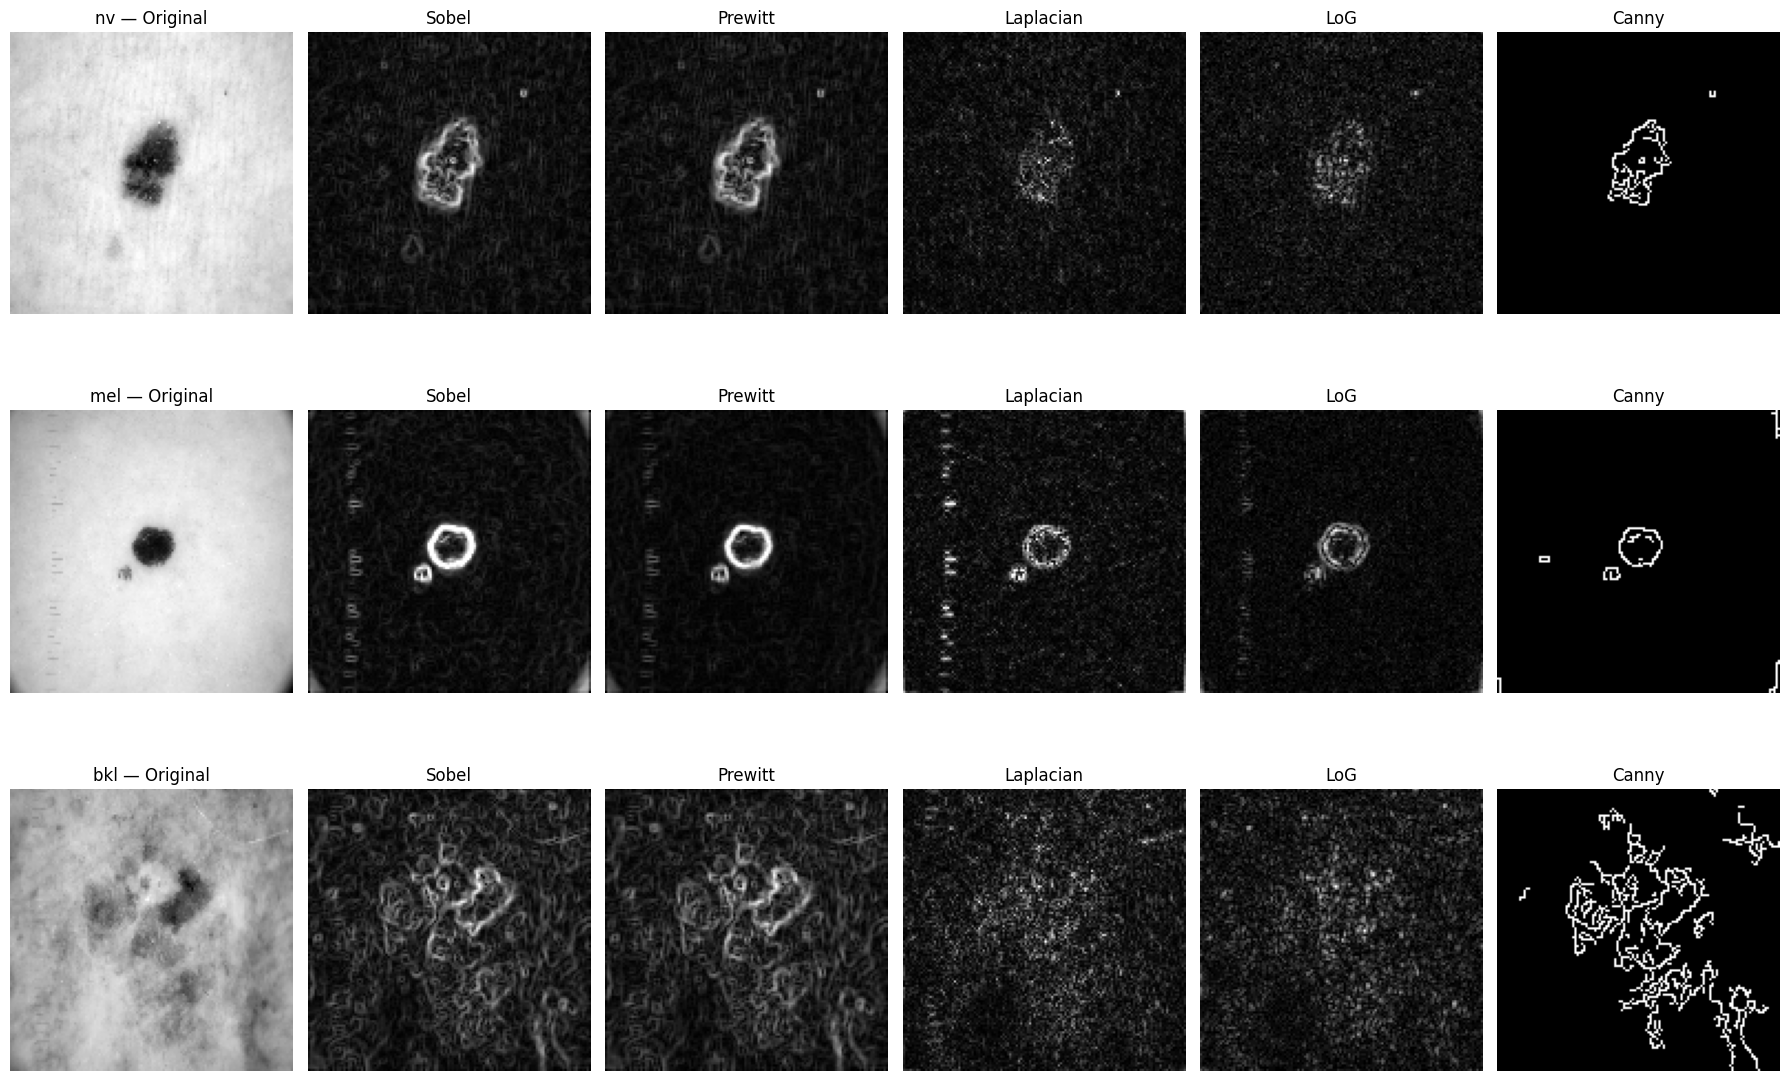

In [7]:
fig, axes = plt.subplots(len(sample_classes), len(methods) + 1, figsize=(18, 4 * len(sample_classes)))

for row, (cls, img) in enumerate(sample_images.items()):
    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title(f"{cls} — Original")
    axes[row, 0].axis("off")
    for col, (name, fn) in enumerate(methods.items(), start=1):
        axes[row, col].imshow(fn(img), cmap="gray")
        axes[row, col].set_title(name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("task1_edge_comparison.png", dpi=150)
plt.show()

## 4. Task 2 — Effect of Noise and Preprocessing on Edge Detection

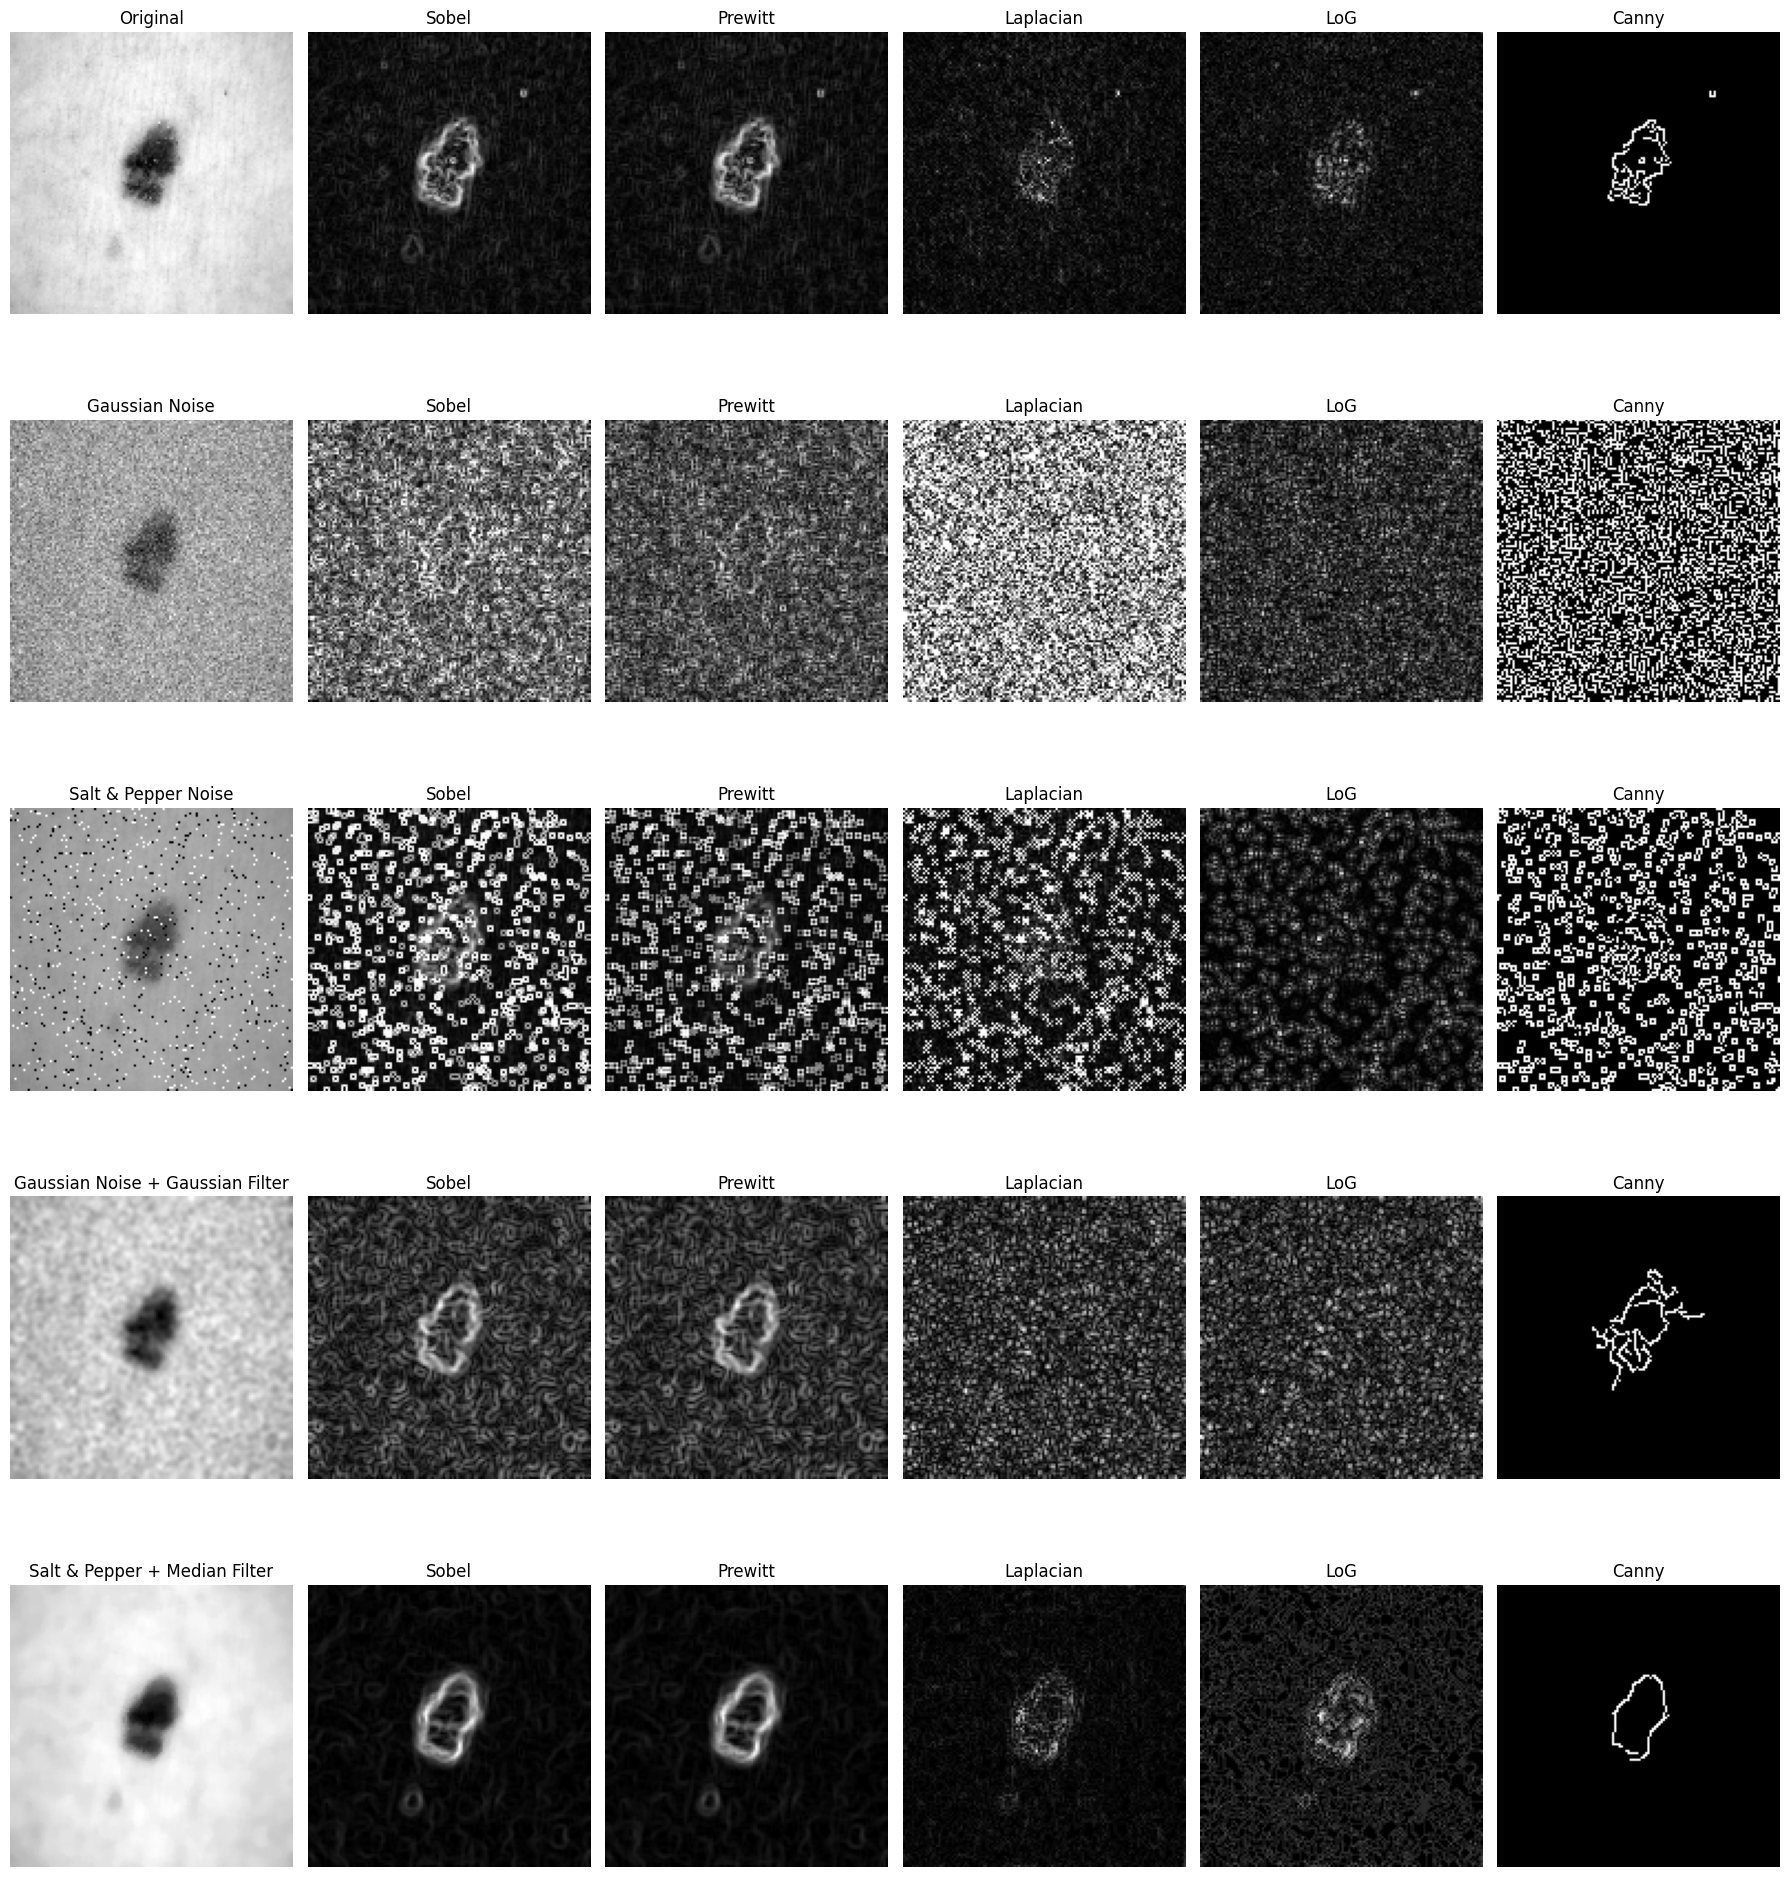

In [8]:
def add_gaussian_noise(img, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def add_salt_pepper(img, prob=0.05):
    noisy = img.copy()
    rnd = np.random.rand(*img.shape)
    noisy[rnd < prob / 2] = 0
    noisy[rnd > 1 - prob / 2] = 255
    return noisy

ref_img = sample_images["nv"]
gauss_noisy = add_gaussian_noise(ref_img)
sp_noisy = add_salt_pepper(ref_img)
gauss_filtered = cv2.GaussianBlur(gauss_noisy, (5, 5), 0)
median_filtered = cv2.medianBlur(sp_noisy, 5)

rows = [
    ("Original", ref_img),
    ("Gaussian Noise", gauss_noisy),
    ("Salt & Pepper Noise", sp_noisy),
    ("Gaussian Noise + Gaussian Filter", gauss_filtered),
    ("Salt & Pepper + Median Filter", median_filtered),
]

fig, axes = plt.subplots(len(rows), len(methods) + 1, figsize=(18, 4 * len(rows)))
for r, (label, img) in enumerate(rows):
    axes[r, 0].imshow(img, cmap="gray"); axes[r, 0].set_title(label); axes[r, 0].axis("off")
    for c, (name, fn) in enumerate(methods.items(), start=1):
        axes[r, c].imshow(fn(img), cmap="gray"); axes[r, c].set_title(name); axes[r, c].axis("off")

plt.tight_layout()
plt.savefig("task2_noise_effect.png", dpi=150)
plt.show()

In [9]:
def edge_density(edge_img):
    return float(np.mean(edge_img > 0))

table1_rows = [
    ("Sobel", "Original", "None", "None", ref_img),
    ("Sobel", "Noisy", "Gaussian", "None", gauss_noisy),
    ("Sobel", "Noisy", "Salt & Pepper", "None", sp_noisy),
    ("Sobel", "Noisy", "Gaussian", "Gaussian Filter", gauss_filtered),
    ("Sobel", "Noisy", "Salt & Pepper", "Median Filter", median_filtered),
    ("Prewitt", "Original", "None", "None", ref_img),
    ("Laplacian", "Original", "None", "None", ref_img),
    ("LoG", "Noisy", "Gaussian", "Gaussian Filter", gauss_filtered),
    ("Canny", "Original", "None", "Built-in smoothing", ref_img),
    ("Canny", "Noisy", "Gaussian", "Gaussian Filter", gauss_filtered),
    ("Canny", "Noisy", "Salt & Pepper", "Median Filter", median_filtered),
]

table1 = []
for detector, inp, noise, prep, img in table1_rows:
    edge_img = methods[detector](img)
    table1.append({
        "Edge Detector": detector, "Input Image": inp, "Noise Type": noise,
        "Preprocessing": prep, "Edge Density": round(edge_density(edge_img), 4),
    })

table1_df = pd.DataFrame(table1)
table1_df.to_csv("table1_noise_preprocessing.csv", index=False)
table1_df

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Density
0,Sobel,Original,None,None,0.9952
1,Sobel,Noisy,Gaussian,None,0.9995
2,Sobel,Noisy,Salt & Pepper,None,0.9963
3,Sobel,Noisy,Gaussian,Gaussian Filter,0.9987
4,Sobel,Noisy,Salt & Pepper,Median Filter,0.9427
5,Prewitt,Original,None,None,0.9963
6,Laplacian,Original,None,None,0.9598
7,LoG,Noisy,Gaussian,Gaussian Filter,0.9106
8,Canny,Original,None,Built-in smoothing,0.0137
9,Canny,Noisy,Gaussian,Gaussian Filter,0.0182


## 5. Task 3 — Canny Parameter Analysis

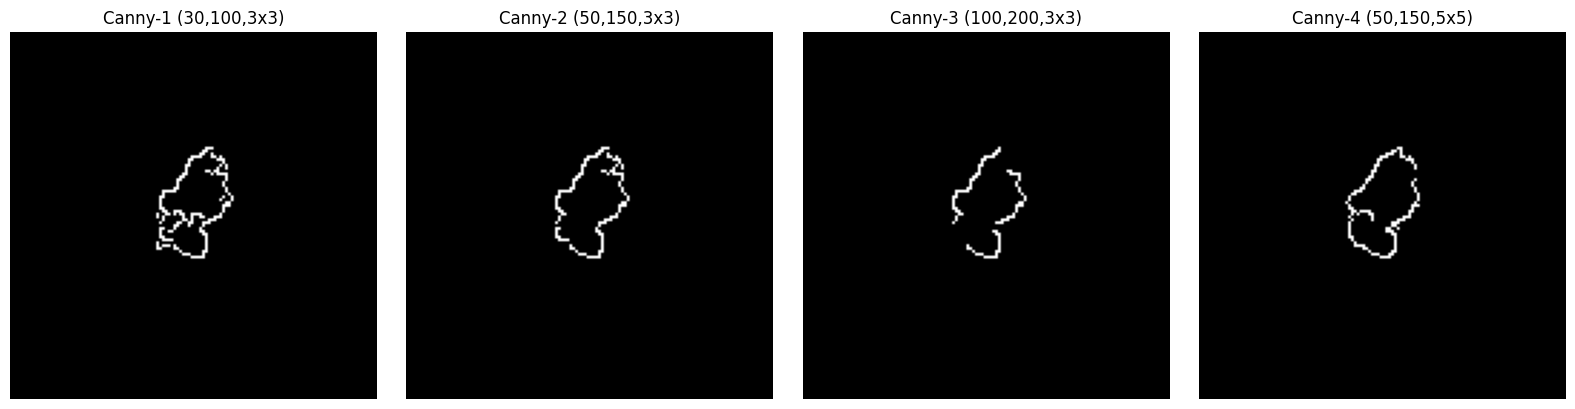

,Configuration,Low Threshold,High Threshold,Kernel Size,Detected Edge Pixels
0,Canny-1,30,100,3x3,169
1,Canny-2,50,150,3x3,131
2,Canny-3,100,200,3x3,102
3,Canny-4,50,150,5x5,130


In [10]:
configs = [
    ("Canny-1", 30, 100, 3),
    ("Canny-2", 50, 150, 3),
    ("Canny-3", 100, 200, 3),
    ("Canny-4", 50, 150, 5),
]

fig, axes = plt.subplots(1, len(configs), figsize=(4 * len(configs), 4))
table2 = []
for ax, (name, low, high, k) in zip(axes, configs):
    blurred = cv2.GaussianBlur(ref_img, (k, k), 0)
    edges = cv2.Canny(blurred, low, high)
    ax.imshow(edges, cmap="gray"); ax.set_title(f"{name} ({low},{high},{k}x{k})"); ax.axis("off")
    table2.append({
        "Configuration": name, "Low Threshold": low, "High Threshold": high,
        "Kernel Size": f"{k}x{k}", "Detected Edge Pixels": int(np.sum(edges > 0)),
    })

plt.tight_layout()
plt.savefig("task3_canny_params.png", dpi=150)
plt.show()

table2_df = pd.DataFrame(table2)
table2_df.to_csv("table2_canny_params.csv", index=False)
table2_df

In [11]:
BEST_LOW, BEST_HIGH, BEST_K = 50, 150, 3  # update after inspecting Task 3 results

## 6. Task 4 — Dataset Preparation (Raw / Filtered / Edge)

In [12]:
def to_edge_map(img):
    blurred = cv2.GaussianBlur(img, (BEST_K, BEST_K), 0)
    return cv2.Canny(blurred, BEST_LOW, BEST_HIGH)

def to_filtered(img):
    return cv2.GaussianBlur(img, (5, 5), 0)  # best filter identified in Lab02

class SkinLesionDataset(Dataset):
    def __init__(self, df, mode):
        self.paths = df["path"].values
        self.labels = df["label"].values
        self.mode = mode  # "raw" | "filtered" | "edge"

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = load_gray(self.paths[idx])
        if self.mode == "filtered":
            img = to_filtered(img)
        elif self.mode == "edge":
            img = to_edge_map(img)
        img = img.astype(np.float32) / 255.0
        return torch.tensor(img).unsqueeze(0), int(self.labels[idx])

datasets = {
    "raw": {s: SkinLesionDataset(d, "raw") for s, d in [("train", train_df), ("val", val_df), ("test", test_df)]},
    "filtered": {s: SkinLesionDataset(d, "filtered") for s, d in [("train", train_df), ("val", val_df), ("test", test_df)]},
    "edge": {s: SkinLesionDataset(d, "edge") for s, d in [("train", train_df), ("val", val_df), ("test", test_df)]},
}

## 7. Task 5 — Classification Using Raw / Filtered / Edge Images

In [13]:
def flatten_set(ds, resize_to=32, max_samples=None):
    # classical models train on a smaller resize (32x32) — full 128x128 pixel
    # vectors make RBF-SVM extremely slow; this keeps signal, keeps it fast.
    n = len(ds) if max_samples is None else min(len(ds), max_samples)
    idx = np.random.choice(len(ds), size=n, replace=False) if max_samples else range(len(ds))
    X, y = [], []
    for i in idx:
        img_t, label = ds[i]
        img = img_t.numpy().squeeze(0)
        img = cv2.resize(img, (resize_to, resize_to))
        X.append(img.flatten())
        y.append(label)
    return np.array(X), np.array(y)

MAX_TRAIN_SAMPLES = 2500  # cap for SVM/RF/KNN — keeps training under ~1-2 min each

classical_models = {
    "SVM": SVC(kernel="linear"),  # linear kernel: much faster than RBF at this scale
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * (IMG_SIZE // 8) ** 2, 128),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def train_cnn(train_ds, val_ds, epochs=5, lr=1e-3, batch_size=32):
    model = SimpleCNN(num_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    return model

def evaluate_cnn(model, test_ds, batch_size=32):
    loader = DataLoader(test_ds, batch_size=batch_size)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(labels), np.array(preds)

In [15]:
results = []
preds_store = {}

for variant in ["raw", "filtered", "edge"]:
    print(f"=== Variant: {variant} ===", flush=True)
    print("  loading + resizing images...", flush=True)
    X_train, y_train = flatten_set(datasets[variant]["train"], max_samples=MAX_TRAIN_SAMPLES)
    X_test, y_test = flatten_set(datasets[variant]["test"])
    print(f"  train shape: {X_train.shape}, test shape: {X_test.shape}", flush=True)

    for name, model in classical_models.items():
        print(f"  training {name}...", flush=True)
        t0 = time.time(); model.fit(X_train, y_train); train_time = time.time() - t0
        t0 = time.time(); preds = model.predict(X_test); infer_time = (time.time() - t0) * 1000 / len(X_test)
        print(f"  {name} done in {train_time:.1f}s (train)", flush=True)
        results.append({
            "Model": name, "Variant": variant,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, average="weighted", zero_division=0),
            "Recall": recall_score(y_test, preds, average="weighted", zero_division=0),
            "F1": f1_score(y_test, preds, average="weighted", zero_division=0),
            "Train Time (s)": round(train_time, 2), "Inference Time (ms)": round(infer_time, 3),
        })
        preds_store[(name, variant)] = (y_test, preds)

    print("  training CNN...", flush=True)
    t0 = time.time()
    cnn = train_cnn(datasets[variant]["train"], datasets[variant]["val"])
    train_time = time.time() - t0
    t0 = time.time()
    y_true, preds = evaluate_cnn(cnn, datasets[variant]["test"])
    infer_time = (time.time() - t0) * 1000 / len(y_true)
    print(f"  CNN done in {train_time:.1f}s (train)", flush=True)
    results.append({
        "Model": "CNN", "Variant": variant,
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, preds, average="weighted", zero_division=0),
        "F1": f1_score(y_true, preds, average="weighted", zero_division=0),
        "Train Time (s)": round(train_time, 2), "Inference Time (ms)": round(infer_time, 3),
    })
    preds_store[("CNN", variant)] = (y_true, preds)

print("=== ALL DONE ===", flush=True)
results_df = pd.DataFrame(results)
results_df.to_csv("table3_classification_results.csv", index=False)
results_df

=== Variant: raw ===
  loading + resizing images...
  train shape: (2500, 1024), test shape: (1503, 1024)
  training SVM...
  SVM done in 4.7s (train)
  training Random Forest...
  Random Forest done in 8.4s (train)
  training KNN...
  KNN done in 0.0s (train)
  training CNN...
  CNN done in 826.0s (train)
=== Variant: filtered ===
  loading + resizing images...
  train shape: (2500, 1024), test shape: (1503, 1024)
  training SVM...
  SVM done in 4.1s (train)
  training Random Forest...
  Random Forest done in 9.4s (train)
  training KNN...
  KNN done in 0.0s (train)
  training CNN...
  CNN done in 797.3s (train)
=== Variant: edge ===
  loading + resizing images...
  train shape: (2500, 1024), test shape: (1503, 1024)
  training SVM...
  SVM done in 4.0s (train)
  training Random Forest...
  Random Forest done in 3.3s (train)
  training KNN...
  KNN done in 0.0s (train)
  training CNN...
  CNN done in 794.7s (train)
=== ALL DONE ===


,Model,Variant,Accuracy,Precision,Recall,F1,Train Time (s),Inference Time (ms)
0,SVM,raw,0.677977,0.580618,0.677977,0.598782,4.70,1.500
1,Random Forest,raw,0.686627,0.594646,0.686627,0.605585,8.37,0.052
2,KNN,raw,0.662009,0.571868,0.662009,0.591686,0.00,0.267
3,CNN,raw,0.686627,0.598528,0.686627,0.605074,826.03,13.985
4,SVM,filtered,0.675316,0.579108,0.675316,0.592979,4.13,0.809
5,Random Forest,filtered,0.693280,0.610543,0.693280,0.608778,9.41,0.038
6,KNN,filtered,0.667997,0.584100,0.667997,0.599303,0.00,0.201
7,CNN,filtered,0.687957,0.583403,0.687957,0.606122,797.26,12.510
8,SVM,edge,0.599468,0.546258,0.599468,0.568976,3.95,1.138
9,Random Forest,edge,0.660013,0.521323,0.660013,0.560400,3.27,0.051


## 8. Task 6 — Confusion Matrices and Performance Comparison

In [16]:
best_model = results_df.groupby("Model")["Accuracy"].mean().idxmax()
best_model

'Random Forest'

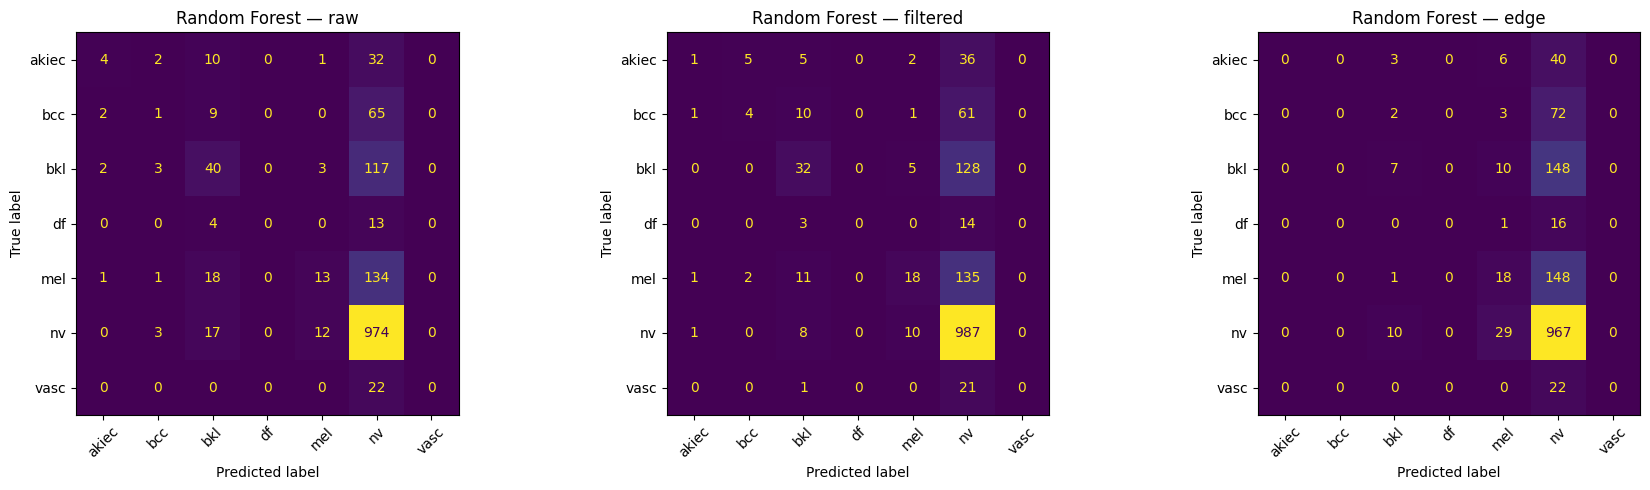

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, variant in zip(axes, ["raw", "filtered", "edge"]):
    y_true, preds = preds_store[(best_model, variant)]
    cm = confusion_matrix(y_true, preds)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{best_model} — {variant}")

plt.tight_layout()
plt.savefig("task6_confusion_matrices.png", dpi=150)
plt.show()

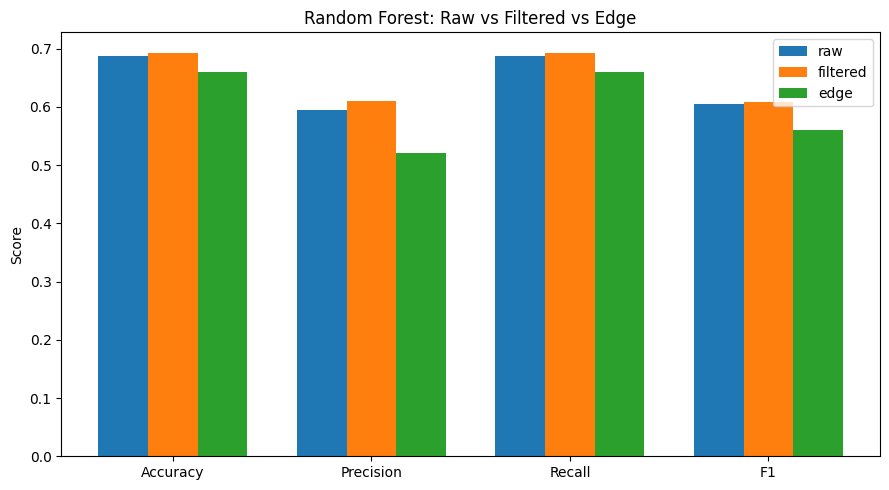

In [18]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
variants = ["raw", "filtered", "edge"]
sub = results_df[results_df["Model"] == best_model].set_index("Variant")

x = np.arange(len(metrics)); width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, variant in enumerate(variants):
    vals = [sub.loc[variant, m] for m in metrics]
    ax.bar(x + (i - 1) * width, vals, width, label=variant)

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Score"); ax.set_title(f"{best_model}: Raw vs Filtered vs Edge")
ax.legend()
plt.tight_layout()
plt.savefig("task6_bar_comparison.png", dpi=150)
plt.show()

## 9. Outputs

All figures (`task1_edge_comparison.png`, `task2_noise_effect.png`, `task3_canny_params.png`, `task6_confusion_matrices.png`, `task6_bar_comparison.png`) and tables (`table1_noise_preprocessing.csv`, `table2_canny_params.csv`, `table3_classification_results.csv`) are saved in the working directory for the report.

Discussion questions, viva answers, and the full write-up are in `README.md` (kept outside this notebook).